<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 3.1: Fast Pricing with Neural Networks </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>


# Obectives

- Learn a neural surrogate model to approximate option prices computed by Monte Carlo.
- Study the accuracy of the surrogate and MC pricers, compared to the Benchmark Black Scholes formula
- Study the computing time performance

We focus on a **European call** in the **Black–Scholes** model, so that we can easily generate option prices with **Monte Carlo** (slow but flexible) and check accuracy against the **closed-form Black–Scholes formula**

**Inputs** (features): $x = (\sigma, r, S_0, K, T)$

**Output** (target): option price $y=F(x)$.

> You will build:  
> **(1)** Monte Carlo pricer,
>
> **(2)** Dataset generator,
>
> **(3)** MLP surrogate $F_\theta(x) \approx F(x)$,
>
> **(4)** Evaluation + speed benchmark.

## 0. Setup

In [1]:
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from time import perf_counter
import joblib

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Black–Scholes: closed-form formula (reference)

For a European call:
\begin{equation}
P^\text{call}_t = S_0 N(d_1) - K e^{-r(T-t)}N(d_2),
\end{equation}
with
\begin{equation}
d_1=\frac{\ln(S_t/K)+(r+\tfrac12\sigma^2)(T-t)}{\sigma\sqrt{T-t}},
\quad
d_2=d_1-\sigma\sqrt{T-t}.
\end{equation}

### Remark
The normal cumulative distribution function $N$ can be computed with 'norm.cdf' function in Scipy

<span style="color: blue;">**1.1** Implement the Black-Scholes formula in a function `Black_Scholes_Formula` taking inputs S0, K, T, sigma, r.</span>

<span style="color: blue;">**1.2** Check your code with S0=K=100, T = 1 year, sigma = 20% and r=1%.</span> 

Expected result $P_0^\text{call} =$ `8.433318690109608`.

In [2]:
def Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity):
    r"""
    Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity)
    Function computing the Black-Scholes formula to obtain the price of a Call option
    
    Inputs
    ----------
    vol            : volatility of the underlying
    risk_free_rate : value of the risk free rate
    current_price  : current value of the underlying price (X_t)
    strike         : value of the strike (K)
    maturity       : Maturity of the option (T-t)

    Output
    -------
    Value          : Call option price from BS formula : X0 \Phi(d_1) - K e^{-r(T_t)} \Phi(d_2)
    """
    # Computation of d_1 and d_2 of the Black-Scholes Formula
    d_1 = (np.log(current_price/strike) + (risk_free_rate + 0.5 * vol**2)*maturity)/(vol * np.sqrt(maturity))
    d_2 = d_1 - vol * np.sqrt(maturity)
    # Black-Scholes formula
    Value = current_price * norm.cdf(d_1) - strike * np.exp(- risk_free_rate * maturity) * norm.cdf(d_2)
    return Value

# Quick sanity check
print(Black_Scholes_Formula(0.2, 0.01, 100, 100, 1.0))

8.433318690109608


## 2. Monte Carlo pricer

Under risk-neutral measure:
\begin{equation}
\frac{dS_t}{S_t} = r dt + \sigma dW_t, 
\end{equation}
which results, by integration:
\begin{equation}
S_T = S_t \exp\left((r-\tfrac12\sigma^2)(T-t)+\sigma\sqrt{T-t}Z\right),\quad Z\sim\mathcal N(0,1).
\end{equation}
Assuming AOA, the price of a Call option of strike $K$ and maturity $T$ is given by the expectation of the discounted payoff:
\begin{equation}
C = \mathbb{E}\left[e^{-r(T-t)} (S_T - K)^+ | S_t \right]
\end{equation}
The objective is to approximate this value by Monte Carlo:
\begin{equation}
C \approx e^{-r(T-t)}\frac{1}{N}\sum_{n=1}^N (S_T^{(n)}-K)_+.
\end{equation}

<span style="color: blue;">**2.1** Implement the Black-Scholes formula in a function `ms_call_price` taking inputs S0, K, T, sigma, r, and a number of simulation n_simulations.</span>

<span style="color: blue;">**2.2** Study the Monte Carlo error with respect to the true option value, with `n_simulations=` 1000, 10000, 100000.</span>

<span style="color: blue;">**2.3** How can we really study the decreasing error with the number of simulations ? 🤔 </span>

In [3]:
def mc_call_price(sigma, r, S0, K, Tmt, n_simulations=20000) -> float:
    """
    Computes the Call option prices from Monte Carlo simulations
    sigma, r, S0, K, Tmt: parameters of the Call option
    n_simulations: number of simulations in the Monte Carlo approximation
    """
    Z = np.random.randn(n_simulations)

    S_T = S0 * np.exp((r - 0.5 * sigma**2) * Tmt + sigma * np.sqrt(Tmt) * Z)
    CF = np.maximum(S_T - K, 0.0)
    return np.exp(-r*Tmt) * np.mean(CF)

# Compare MC vs BS on one example
sigma,r, S0,K,Tmt = 0.2, 0.01, 100, 100, 1.0
for N in [1000, 10000, 100000]:
    mc = mc_call_price(sigma,r, S0,K,Tmt,n_simulations=N)
    bs = Black_Scholes_Formula(sigma,r, S0,K,Tmt)
    print(f"N={N:>6} | MC={mc:.4f} | BS={bs:.4f} | abs err={abs(mc-bs):.4f}")

N=  1000 | MC=7.8102 | BS=8.4333 | abs err=0.6232
N= 10000 | MC=8.2277 | BS=8.4333 | abs err=0.2056
N=100000 | MC=8.4513 | BS=8.4333 | abs err=0.0179


## 3. Dataset generation

The objective is to randomly sample parameters in the training domain $\mathcal{D}_{\text{domain}}$. For example:
- $\sigma\in [0.05,0.6]$
- $r\in [0,0.05]$
- $S_0\in [250,350]$
- $K\in [5,600]$
- $T - t\in [0.5,1.5]$

One can use function `np.random.uniform(p_min, p_max, size=n)` to uniformly draw n samples of a parameter $p$ between p_min and p_max

And, for each $x \in \mathcal{D}_\text{domain}$, we then compute Monte Carlo prices $y$.

<span style="color: blue;">**3.1** Implement a function `build_dataset(n_samples, n_simulations)` that builds a dataset $(x_i, y_i) \in \mathcal{D}_\text{domain}$, for $i=1, \dots,$ n_samples, by using Monte Carlo pricing with n_simulations.  </span> 


<span style="color: blue;">**3.2** Use this funcion to generate a dataset of 10,000 samples, and split the data set in X_train, y_train, X_val, y_val, X_test, y_test with a respective repartition (50%, 10%, 40%).  </span> (Advice: one can take inspiration from the function `time_plit` implemented in Tutorial 1, but adapt it since we are not working with time series !)


In [4]:
def sample_domain(n_samples):
    """
    Generates samples of sets (sigma, r, S0, K, T) of parameters used in 
    the Black-Scholes formula
    Input:
    n_samples := number of samples
    Output:
    X := set of samples of (sigma, r, S0, K, T)
    """
    # Uniformly draw (using np.random.uniform) n samples x in the training domain   
    sigma = np.random.uniform(0.05, 0.6, size=n_samples)
    r  = np.random.uniform(0.0, 0.05, size=n_samples)
    S0 = np.random.uniform(250, 350, size=n_samples)
    K  = np.random.uniform(5, 600, size=n_samples)
    Tmt  = np.random.uniform(0.5, 1.5, size=n_samples)
    X = np.stack([sigma, r, S0, K, Tmt], axis=1)
    return X

def build_dataset(n_samples, n_simulations, verbose=True):
    """
    Builds a dataset of call option prices from inputs X = (S0, K, T, sigma, r)
    with Monte Carlo method

    Inputs
    ------
    n_samples: number of computed options prices = nb of lines in X
    n_simulation: number of simulations used in the MC pricer
    verbose: boolean to print information

    Output
    -----
    (X,y): dataset of x and y=F(x)
    """
    X = sample_domain(n_samples)
    y = np.empty((n_samples,), dtype=np.float32)
    t0 = perf_counter()
    for i in range(n_samples):
        y[i] = mc_call_price(*X[i], n_simulations=n_simulations)
        if verbose and (i+1) % max(1, n_samples//10) == 0:
            print(f"{i+1}/{n_samples} done")
    t1 = perf_counter()
    if verbose:
        print(f"Dataset generated in {t1-t0:.2f}s (n_samples={n_samples}, n_simulations={n_simulations})")
    return X, y.reshape(-1,1)


def data_split(X, y, train_frac=0.7, val_frac=0.15):
    """
    Randomly Split dataset (X,y) in (X_train, y_train), (X_val, y_val), (X_test, y_test)
    if permutation = False, the split is temporal
    Inputs
    ----------
    X : np.ndarray, shape (n_samples, d)
    y : np.ndarray, shape (n_samples, 1)
    train_frac : float, fraction for X_train size (default value 0.7)
    val_frac   : float, fraction for X_ val size (default value 0.15)

    Output
    ------
    (X_train, y_train), (X_val, y_val), (X_test, y_test)

    """

    # Lengths    
    n = X.shape[0]   
    ny = y.shape[0]
    # Check of equal number of samples
    if n != ny:
        raise ValueError(f"X and y must have the same number of samples (X:{n}, y:{ny})")

    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    
    # Random permutation of the samples
    idx = np.random.permutation(n)
    
    # Split indices
    idx_train = idx[:n_train]
    idx_val   = idx[n_train:n_train + n_val]
    idx_test  = idx[n_train + n_val:]


    # Split Data
    X_train, y_train = X[idx_train], y[idx_train]
    X_val,   y_val   = X[idx_val],   y[idx_val]
    X_test,  y_test  = X[idx_test],  y[idx_test]
        
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


n_simulations = 50000
n_sample = 10000
# Generate a small dataset for quick iteration
X, y = build_dataset(n_samples=n_sample, n_simulations=n_simulations, verbose=True)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = data_split(X, y, 0.5, 0.1)
list(map(len, [X_train, X_val, X_test]))

1000/10000 done
2000/10000 done
3000/10000 done
4000/10000 done
5000/10000 done
6000/10000 done
7000/10000 done
8000/10000 done
9000/10000 done
10000/10000 done
Dataset generated in 19.27s (n_samples=10000, n_simulations=50000)


[5000, 1000, 4000]

## 4.0 Preprocessing: scaling

Neural networks train much better if inputs and outputs are standardized.

We apply, on all the data (train, val and test):
\begin{equation}
X^i_{\text{s}} = (X^i - \mu_X^i)/\sigma_X^i
\end{equation}
and 
\begin{equation}
y_{\text{s}} = (y - \mu_y)/\sigma_y
\end{equation}
with $(\mu_X^i, \sigma_X^i)$, $i=1,\dots, d$ and $(\mu_y, \sigma_y)$ are mean and standard deviation estimated only on the training dataset

**Nota ! : in the end, we save the scaling parameters in `Data/scaler_X.joblib` and `Data/scaler_y.joblib` with package joblib**

In [5]:
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train) 
y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Transform Dataset in Torch objects
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train_s,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val_s,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test_s,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Sanity check
print("X_train mean (approx):", X_train_s.mean(axis=0))
print("X_train std  (approx):", X_train_s.std(axis=0))

# Saving scaling parameters
joblib.dump(scaler_X, "scaler_X.joblib")
joblib.dump(scaler_y, "scaler_y.joblib")

X_train mean (approx): [-9.76996262e-19  2.85576007e-15  4.44688730e-15 -1.48383528e-15
  6.47997767e-15]
X_train std  (approx): [1. 1. 1. 1. 1.]


['scaler_y.joblib']

## 4. Surrogate model: a simple MLP

Now that all is ready to train a Neural Network, we consider a simple MLP surrogate model.

We propose a fully-connected network:
- **input dim:** 5 (features $S_0$; $K$, $T$, $\sigma$, $r$ standardized)
- **Hidden layers:** 3 layers with sizes 128 --> 128 --> 64, all with ReLU
- **Output dim:** 1 (scaled (standardized) price)
- **Loss function:** MSE (nn.MSELoss)
- **Optimizer:** Adam (Learning rate 1e$^{-3}$

<span style="color: blue;">**4.1** Build the class MLP with the above characteristics  </span>

<span style="color: blue;">**4.2** Implement the function `run_epoch(loader, train)` that runs one epoch</span>
- <span style="color: blue;">sets model.train() if train=True otherwise model.eval()</span>
- <span style="color: blue;">iterates over the loader, sends</span>
- <span style="color: blue;">returns the losses </span>

<span style="color: blue;">**4.3** Implement the training procedure on 250 Epochs, with an overfitting control  </span>
- <span style="color: blue;">with a patience counter of 20 (if no loss decrease during 20 Epochs, then stop</span>
- <span style="color: blue;">save the best model in `Data/best_mlp.pt`</span>

<span style="color: blue;">**4.4** Plot the MSE losses (Learning Curves) for the train and val sets  </span>

Epoch 020 | Train MSE=0.000226 | Val MSE=0.000373
Epoch 040 | Train MSE=0.000171 | Val MSE=0.000241
Epoch 060 | Train MSE=0.000093 | Val MSE=0.000156
Epoch 080 | Train MSE=0.000349 | Val MSE=0.000386
Epoch 100 | Train MSE=0.000077 | Val MSE=0.000131
Epoch 120 | Train MSE=0.000222 | Val MSE=0.000179
Early stopping.


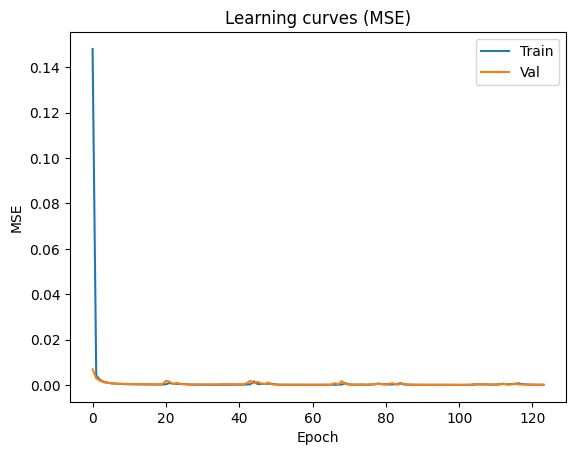

In [6]:
# Training with early stopping on validation RMSE
import math
best_val = math.inf
patience= 20
EPOCHS = 250
file_save_best_model = "fast_pricing_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)


model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader, train=False):
    if train: model.train()
    else: model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)


patience_cnt = 0
train_data, val_data = [], []
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(train_loader, train=True) # Can mix the order since we are not working with time series
    va = run_epoch(val_loader,   train=False) # Must keep the order to match with predicted value
    train_data.append(tr); val_data.append(va)
    val_mse = va
    if val_mse < best_val - 1e-6:
        best_val = val_mse
        patience_cnt = 0
        torch.save(model.state_dict(), file_save_best_model)
    else:
        patience_cnt += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train MSE={tr:.6f} | Val MSE={val_mse:.6f}")
    if patience_cnt >= patience:
        print("Early stopping.")
        break

plt.figure()
plt.plot(train_data)
plt.plot(val_data)
plt.title("Learning curves (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train","Val"])
plt.show()

## 5. Evaluation (accuracy)

Now the surrogate model is trained, let's evaluate its performance on the test set

<span style="color: blue;">**5.1** Load the best model saved in `file_save_best_model` and the scaling parameters with command `joblib.load` and evaluate with `model.eval()`</span>

<span style="color: blue;">**5.2** Compute the predicted `y_test_pred` from X_test (test_loader tensor) and unscale to get `y_test_hat`</span>

<span style="color: blue;">**5.3** Compute the MAE and RMSE, and give the scatter plot MC price vs. NN price </span>

<span style="color: blue;">**5.4** Give the scatter plot BS price vs. NN price </span>

<span style="color: blue;">**5.5** Redo the evaluation in a new dataset `X_new` </span>



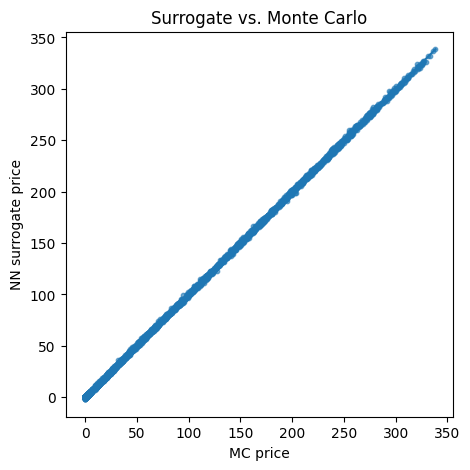

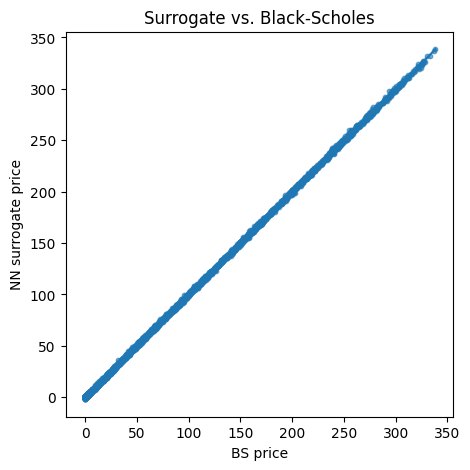

100/1000 done
200/1000 done
300/1000 done
400/1000 done
500/1000 done
600/1000 done
700/1000 done
800/1000 done
900/1000 done
1000/1000 done
Dataset generated in 1.98s (n_samples=1000, n_simulations=50000)


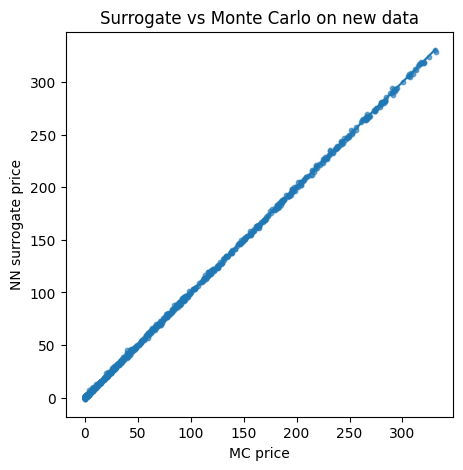

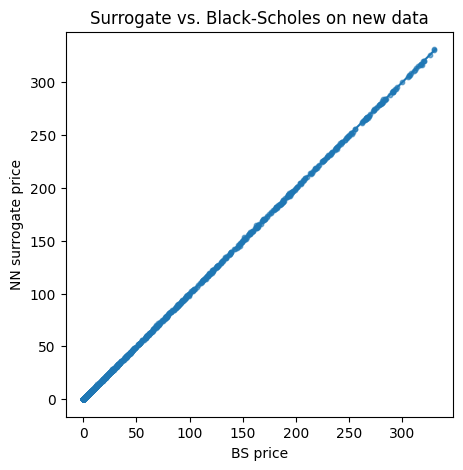

In [7]:
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Also import the scaling parameters
scaler_X = joblib.load("scaler_X.joblib")
scaler_y = joblib.load("scaler_y.joblib")
                       
# Prediction on the test set
with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_test_pred.append(model(xb).cpu().numpy())
    y_test_pred = np.concatenate(y_test_pred, axis=0)

# Unscale
y_test_hat = scaler_y.inverse_transform(y_test_pred)
# MAE and RMSE

# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_test_hat, s=10, alpha=0.6)
m = float(min(y_test.min(), y_test_hat.min()))
M = float(max(y_test.max(), y_test_hat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("MC price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Monte Carlo")
plt.show()


##########################################
# BS vs. NN
# Compute Black-Scoles prices
sigma = X_test[:,0]
r = X_test[:,1]
S0 = X_test[:,2]
K = X_test[:,3]
Tmt = X_test[:,4]

y_bs = Black_Scholes_Formula(sigma, r, S0, K, Tmt)
# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_bs, y_test_hat, s=10, alpha=0.6)
m = float(min(y_bs.min(), y_test_hat.min()))
M = float(max(y_bs.max(), y_test_hat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("BS price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Black-Scholes")
plt.show()


n_simulations = 50000
n_sample = 1000
# Generate a small dataset for quick iteration
X_new, y_new = build_dataset(n_samples=n_sample, n_simulations=n_simulations, verbose=True)
X_new_s = scaler_X.transform(X_new)
X_t = torch.from_numpy(X_new_s).float().to(device)


# Inference without gradients + conversion NumPy 2D
with torch.no_grad(): # desactivate the gradient inference
    yhat_s = model(X_t).detach().cpu().numpy() # .cpu(): transfer tensor from gpu to cpu (Numpy can only read tensors in cpu

yhat = scaler_y.inverse_transform(yhat_s)


plt.figure(figsize=(5,5))
plt.scatter(y_new, yhat, s=10, alpha=0.6)
m = float(min(y_new.min(), yhat.min()))
M = float(max(y_new.max(), yhat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("MC price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs Monte Carlo on new data")
plt.show()

##########################################
# BS vs. NN
# Compute Black-Scoles prices
sigma = X_new[:,0]
r = X_new[:,1]
S0 = X_new[:,2]
K = X_new[:,3]
Tmt = X_new[:,4]

y_bs = Black_Scholes_Formula(sigma, r, S0, K, Tmt)
# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_bs, y_new, s=10, alpha=0.6)
m = float(min(y_bs.min(), y_new.min()))
M = float(max(y_bs.max(), y_new.max()))
plt.plot([m, M], [m, M])
plt.xlabel("BS price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Black-Scholes on new data")
plt.show()

## 6. Speed benchmark: Monte Carlo vs NN (online phase)

Consider the new dataset `X_new` previously built.

The objective is to compute, for each parameter set in `X_new`, the call option price with Mnte Carlo and with the surrogate model, and compare the resective computing times. The objective is to illustrate the key message: **pay offline once**, then evaluate extremely fast online.

In order to compute the execution time between two execution lines, we will use `perf_counter` and the followinf structure:
-  `t0 = perf_counter()`
-  command 1
-  command 2
-  ...
-  `t1 = perf_counter()`
The time between the commands lines is then `t1-t0`

<span style="color: blue;">**6.1** Compute the time `t1-t0` of computing the set `y_nn` of call option prices with the surrogate NN model (Do not forget to scale and unscale !)  </span>


<span style="color: blue;">**6.2** Compute the time `t3-t2` of computing the set `y_mc` of call option prices with the Mone Carlo procedure (Needs to do a loop over each parameter set in `X_new`)  </span>

<span style="color: blue;">**6.3** Compare the computation times and evaluate the speed-up  </span>

In [8]:
t0 = perf_counter()
X_new_s = scaler_X.transform(X_new)
X_t = torch.from_numpy(X_new_s).float().to(device)

# Inference without gradients + conversion NumPy 2D
with torch.no_grad(): # desactivate the gradient inference
    yhat_s = model(X_t).detach().numpy() # .detach(): detaches the tensor from the computational graph.

y_nn = scaler_y.inverse_transform(yhat_s)


t1 = perf_counter()

t2 = perf_counter()
n_simulations=200000
y_mc = np.empty((X_new.shape[0],1), dtype=np.float32)
for i in range(X_new.shape[0]):
    y_mc[i,0] = mc_call_price(*X_new[i], n_simulations=n_simulations)
t3 = perf_counter()

n_prices = X_t.shape[0]
print(f"NN time for {n_prices} prices: {(t1-t0):.4f}s")
print(f"MC time for {n_prices} prices: {(t3-t2):.4f}s  (n_simulations={n_simulations})")
print(f"Speed-up ≈ {(t3-t2)/(t1-t0):.1f}x")

NN time for 1000 prices: 0.1750s
MC time for 1000 prices: 16.9355s  (n_simulations=200000)
Speed-up ≈ 96.7x


## 7. Limits: domain of validity (extrapolation)

The final objective is to illustrate that the surrogate model, as a fast pricing model, must be used **inside** its validity domain, i.e. inside the domain $\mathcal{D}_\text{domain}$ where it has been trained.
- $\sigma\in [0.05,0.6]$
- $r\in [0,0.05]$
- $S_0\in [250,350]$
- $K\in [5,600]$
- $T - t\in [0.5,1.5]$

For this, we will sample a new dataset (X, y) with values outside $\mathcal{D}_\text{domain}$ (we will only sample $S_0$ outside $\mathcal{D}_\text{domain}$), and compare the call option prices computed with the Black-Scholes formula and the surrgate model.

<span style="color: blue;">**7.1** Build a new dataset `X_extra` by randomly drawing parameters in the following dataset:  </span>
- <span style="color: blue;">$\sigma\in [0.05,0.6]$ </span>
- <span style="color: blue;">$r\in [0,0.05]$ </span>
- <span style="color: blue;">$S_0\in [250,350]$ </span>
- <span style="color: blue;">$K\in [5,600]$ </span>
- <span style="color: blue;">$T - t \in$</span><span style="color: red;"> $[0.5,1.5]$ </span>



<span style="color: blue;">**7.2** Compute the call options prices from Black-Scholes formula (`y_extra_bs`) and the surrogate model (`y_extra_nn`)  </span>

<span style="color: blue;">**7.3** Plot the histogram of errors `y_extra_nn - y_extra_bs` </span>

<span style="color: blue;">**7.4** Conclude about the maturity extrapolation risk </span>

<span style="color: blue;">**7.5** Redo the experiment to study the extrapolation risk of the other parameters </span>



Extrapolation test (S0 in [50,150])  MAE=4.7991  RMSE=7.3857


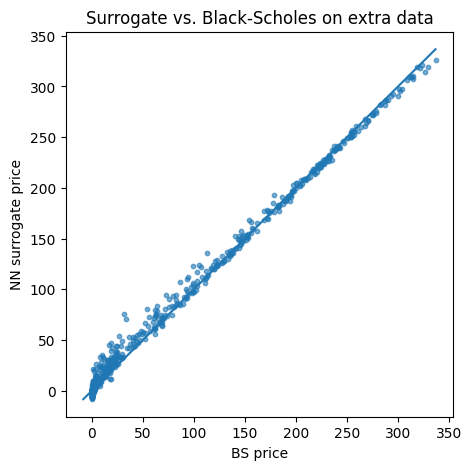

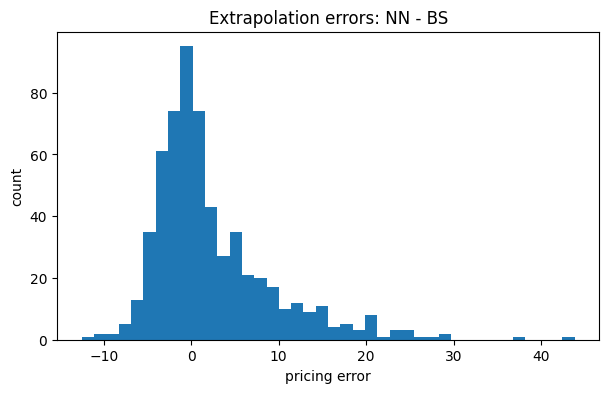

In [9]:
# Extrapolation set (outside the training domain for S0)
n_extra = 600
sigma = np.random.uniform(0.05, 1, size=n_extra)
r  = np.random.uniform(0.0, 0.05, size=n_extra)
S0 = np.random.uniform(250, 350, size=n_extra)
K  = np.random.uniform(5, 600, size=n_extra)
Tmt  = np.random.uniform(0.05, 0.4, size=n_extra)
X_extra = np.stack([sigma, r, S0,K,Tmt], axis=1)

# Ground truth via BS (fast here, but pretend we didn't have it)
y_extra_bs = Black_Scholes_Formula(X_extra[:,0], X_extra[:,1], X_extra[:,2], X_extra[:,3], X_extra[:,4]).reshape(-1,1)

X_extra_s = scaler_X.transform(X_extra)
X_t = torch.from_numpy(X_extra_s).float().to(device)

# Inference without gradients + conversion NumPy 2D
with torch.no_grad(): # desactivate the gradient inference
    yhat_s = model(X_t).detach().cpu().numpy() # .cpu(): transfer tensor from gpu to cpu (Numpy can only read tensors in cpu

y_extra_nn = scaler_y.inverse_transform(yhat_s)

err_extra = y_extra_nn - y_extra_bs
mae_extra = float(np.mean(np.abs(err_extra)))
rmse_extra = float(np.sqrt(np.mean(err_extra**2)))
print(f"Extrapolation test (S0 in [50,150])  MAE={mae_extra:.4f}  RMSE={rmse_extra:.4f}")

plt.figure(figsize=(5,5))
plt.scatter(y_extra_bs, y_extra_nn, s=10, alpha=0.6)
m = float(min(y_extra_bs.min(), y_extra_nn.min()))
M = float(max(y_extra_bs.max(), y_extra_nn.max()))
plt.plot([m, M], [m, M])
plt.xlabel("BS price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Black-Scholes on extra data")
plt.show()


plt.figure(figsize=(7,4))
plt.hist(err_extra.flatten(), bins=40)
plt.title("Extrapolation errors: NN - BS")
plt.xlabel("pricing error")
plt.ylabel("count")
plt.show()

## 8. (Optional) A simple no-arbitrage sanity check

The Surrogate model is just an approximation of the value function, therefore it does not ensure the no-arbitrage property. In particular, the surrogate model does not ensure the monotomicity of the option price with respect to the strike. 

We propose here to check the monotonicity property with respect to the strike and the maturity. 

<span style="color: blue;">**8.1** Set $\sigma = 0.2$, $r=0.01$, $S_0=300$ and $T-t=1$, and build a grid of 500 values of $K$ between 5 and 800 and plot in a same graph the resulting Call prices from the surrogate model and from the Black-Scholes formula. Conclude about the no-arbitrage property. </span> One can use the `np.linespace(v_min, v_max, np_points)` to build the grid of $K$ values.

<span style="color: blue;">**8.2** Redo the experiment with fixed $K=300$ and a grid of 500 values of maturity $T-t$ between 0.5 and 5. Conclude about the no-arbitrage property. </span>

Monotone in S0 (approx): True


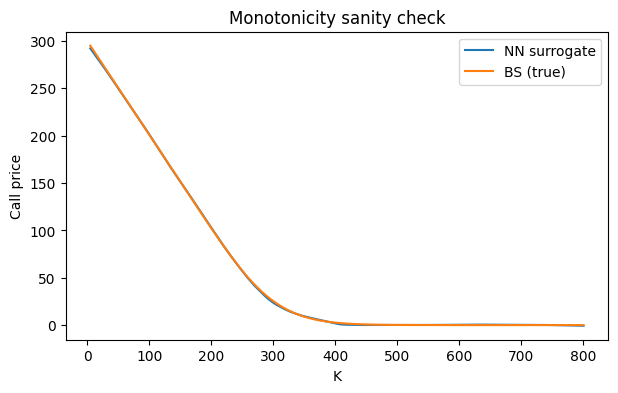

Monotone in S0 (approx): True


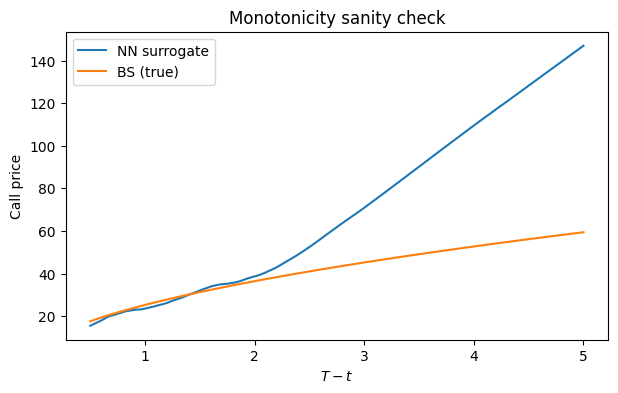

In [10]:
# Fix parameters
S0 = 300.0; Tmt = 1.0; sigma = 0.2; r = 0.01
K_grid = np.linspace(5, 800, 500).astype(np.float32)
X_grid = np.stack([np.full_like(K_grid, sigma), np.full_like(K_grid, r), np.full_like(K_grid, S0), K_grid, np.full_like(K_grid, Tmt)], axis=1)

X_grid_s = scaler_X.transform(X_grid)
X_t = torch.from_numpy(X_grid_s).float().to(device)

# Inference without gradients + conversion NumPy 2D
with torch.no_grad(): # desactivate the gradient inference
    yhat_s = model(X_t).detach().numpy() # .cpu(): transfer tensor from gpu to cpu (Numpy can only read tensors in cpu

y_grid_nn = scaler_y.inverse_transform(yhat_s)


#y_grid_nn = scaler_y.inverse_transform(predict(model, scaler_X.transform(X_grid))).flatten()
is_monotone = np.all(np.diff(y_grid_nn) >= -1e-4)
print("Monotone in S0 (approx):", is_monotone)

plt.figure(figsize=(7,4))
plt.plot(K_grid, y_grid_nn, label="NN surrogate")
plt.plot(K_grid, Black_Scholes_Formula(sigma, r, S0, K_grid, Tmt), label="BS (true)")
plt.xlabel("K")
plt.ylabel("Call price")
plt.title("Monotonicity sanity check")
plt.legend()
plt.show()


K = 300
Tmt_grid = np.linspace(0.5, 5, 500).astype(np.float32)
X_grid = np.stack([np.full_like(Tmt_grid, sigma), np.full_like(Tmt_grid, r), np.full_like(Tmt_grid, S0), np.full_like(Tmt_grid, K), Tmt_grid], axis=1)

X_grid_s = scaler_X.transform(X_grid)
X_t = torch.from_numpy(X_grid_s).float().to(device)

# Inference without gradients + conversion NumPy 2D
with torch.no_grad(): # desactivate the gradient inference
    yhat_s = model(X_t).detach().numpy() # .cpu(): transfer tensor from gpu to cpu (Numpy can only read tensors in cpu

y_grid_nn = scaler_y.inverse_transform(yhat_s)


#y_grid_nn = scaler_y.inverse_transform(predict(model, scaler_X.transform(X_grid))).flatten()
is_monotone = np.all(np.diff(y_grid_nn) >= -1e-4)
print("Monotone in S0 (approx):", is_monotone)

plt.figure(figsize=(7,4))
plt.plot(Tmt_grid, y_grid_nn, label="NN surrogate")
plt.plot(Tmt_grid, Black_Scholes_Formula(sigma, r, S0, K, Tmt_grid), label="BS (true)")
plt.xlabel("$T-t$")
plt.ylabel("Call price")
plt.title("Monotonicity sanity check")
plt.legend()
plt.show()

## 10. What you should remember

- Monte Carlo gives accurate prices, but each call is expensive.
- A neural surrogate learns the pricing function on a training domain.
- **Offline:** simulate + train (costly but done once).  
- **Online:** NN evaluation is extremely fast → useful for repeated calls (calibration, risk, scenario analysis).
- Surrogate accuracy depends on training data quality and domain coverage; extrapolation can fail.